In [4]:
DATA = "/home/ubuntu/data/trimmed.csv"   # change to your file's path

!python borough_complaints.py -i {DATA} -s 2024-01-01 -e 2024-02-29 -o janfeb.csv
!python borough_complaints.py -i {DATA} -s 2024-06-01 -e 2024-07-31 -o junjul.csv

In [5]:
import pandas as pd

janfeb = pd.read_csv("janfeb.csv")
junjul = pd.read_csv("junjul.csv")

totals = janfeb.groupby("complaint type")["count"].sum().sort_values(ascending=False)
print(totals.head(5))

top = totals.index[0]
print("Most abundant:", top)

complaint type
HEAT/HOT WATER          81641
Illegal Parking         79916
Noise - Residential     43602
Blocked Driveway        28608
UNSANITARY CONDITION    19208
Name: count, dtype: int64
Most abundant: HEAT/HOT WATER


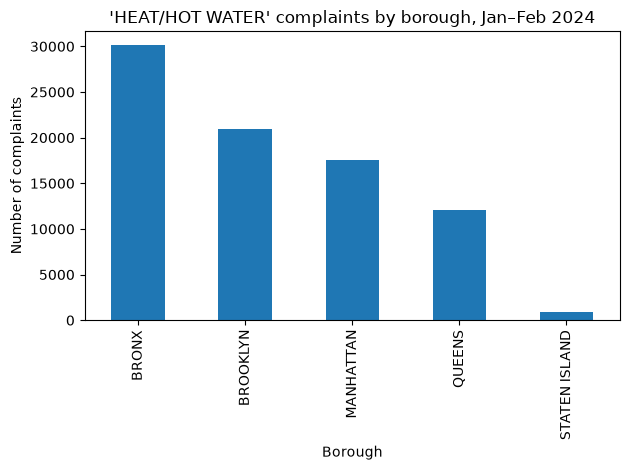

In [6]:
import matplotlib.pyplot as plt

jf = janfeb[janfeb["complaint type"] == top].set_index("borough")["count"]

jf.sort_values(ascending=False).plot(kind="bar")
plt.title(f"'{top}' complaints by borough, Jan–Feb 2024")
plt.xlabel("Borough")
plt.ylabel("Number of complaints")
plt.tight_layout()
plt.show()

               Jan–Feb  Jun–Jul
borough                        
BRONX            30139     2227
BROOKLYN         20915     1929
MANHATTAN        17604     1778
QUEENS           12117      835
STATEN ISLAND      866      121
Totals: {'Jan–Feb': 81641, 'Jun–Jul': 6890}


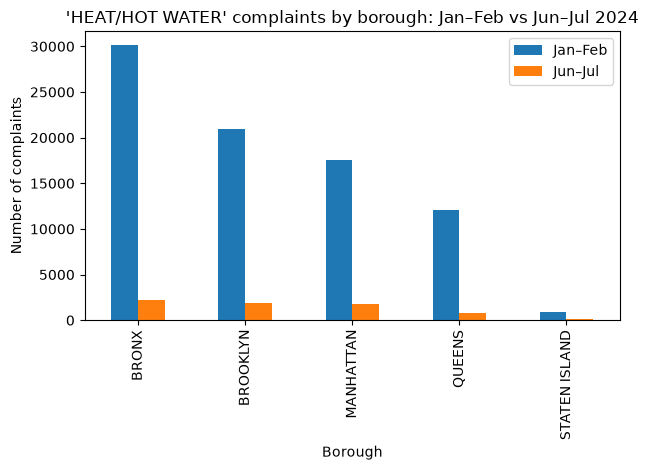

In [7]:
jj = junjul[junjul["complaint type"] == top].set_index("borough")["count"]

compare = pd.DataFrame({"Jan–Feb": jf, "Jun–Jul": jj}).fillna(0)
print(compare)
print("Totals:", compare.sum().to_dict())

compare.plot(kind="bar")
plt.title(f"'{top}' complaints by borough: Jan–Feb vs Jun–Jul 2024")
plt.xlabel("Borough")
plt.ylabel("Number of complaints")
plt.tight_layout()
plt.show()